<a href="https://colab.research.google.com/github/PriyanshuChaubey/SmartCart_Customer_Segmentation_System/blob/main/smartcart(unsupervised_learning)_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df = pd.read_csv("smartcart_customers.csv")

In [34]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [35]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


Data PreProcessing

In [36]:
# Handle Missing Values

df["Income"] = df["Income"].fillna(df["Income"].median())

In [37]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [38]:
# Feature Engineering

df["Age"] = 2026 - df["Year_Birth"]

In [39]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)
reference_data = df["Dt_Customer"].max()
df["Customer_tenure"] = (reference_data - df["Dt_Customer"]).dt.days

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [40]:
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [41]:
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [42]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure,Total_Spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [43]:
 df["Education"] = df["Education"].replace({
    "Basic": "Undergraduate", "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate", "PhD": "Postgraduate"
})

In [44]:
df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Together", "Together": "Together",
    "Divorced": "Alone", "Widow": "Alone", "Alone": "Alone", "Absurd": "Alone", "YOLO": "Alone"
})

In [45]:
cols = ["ID", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer", "Year_Birth"]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
cols_to_drop = cols + spending_cols
df_cleaned = df.drop(columns=cols_to_drop)

outliers

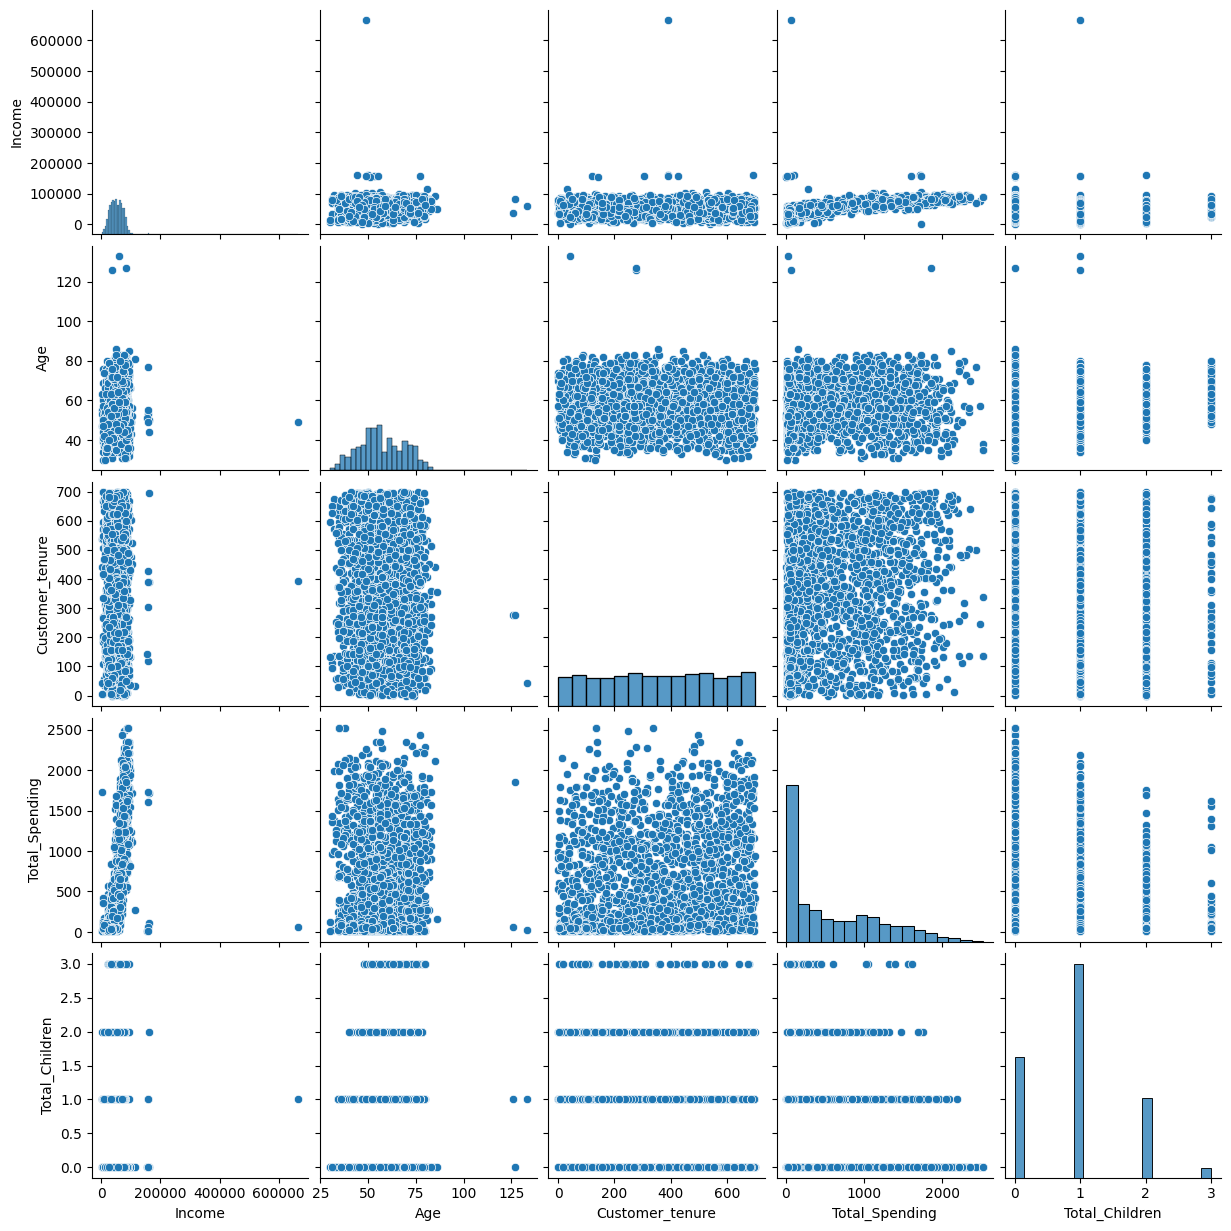

In [46]:
cols = ["Income", "Age", "Customer_tenure", "Total_Spending", "Total_Children"]
sns.pairplot(df_cleaned[cols])

In [47]:
print("length of data size with outliers", len(df_cleaned))
df_cleaned = df_cleaned[df_cleaned["Age"] < 90]
df_cleaned = df_cleaned[df_cleaned["Income"] < 600000]
print("length of data size without outliers", len(df_cleaned))

length of data size with outliers 2240
length of data size without outliers 2236


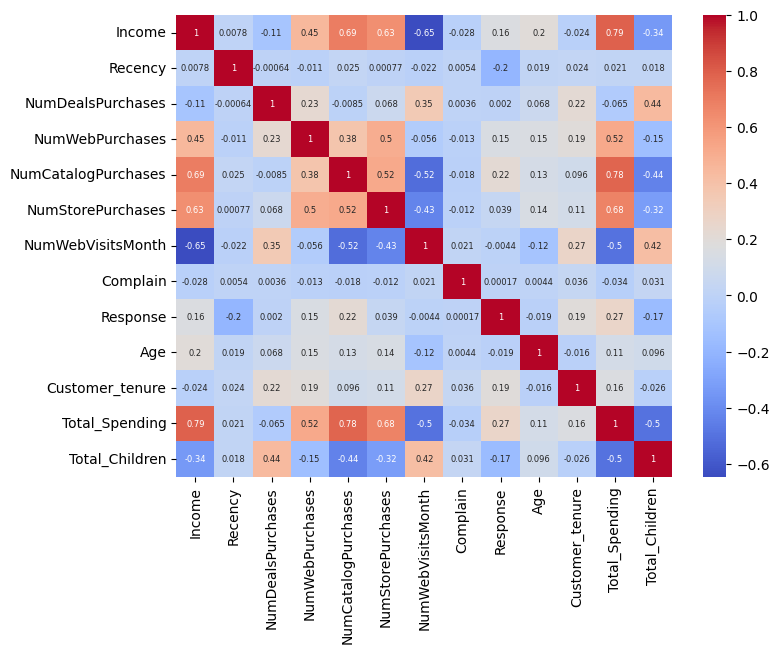

In [48]:
# Heatmap

corr = df_cleaned.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,annot_kws={"size":6}, cmap='coolwarm')
plt.show()


Encoding

In [49]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()
cat_cols = ["Education", "Living_With"]
ene_cols = encoder.fit_transform(df_cleaned[cat_cols])

enc_df = pd.DataFrame(ene_cols.toarray(), columns = encoder.get_feature_names_out(cat_cols), index=df_cleaned.index)
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols), enc_df], axis=1)
df_encoded.shape
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Single,Living_With_Together
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,0.0,1.0


Scaling

In [50]:
from sklearn.preprocessing import StandardScaler
X = df_encoded
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

Visualizing

Text(0.5, 0.92, 'PCA 3D Visualization')

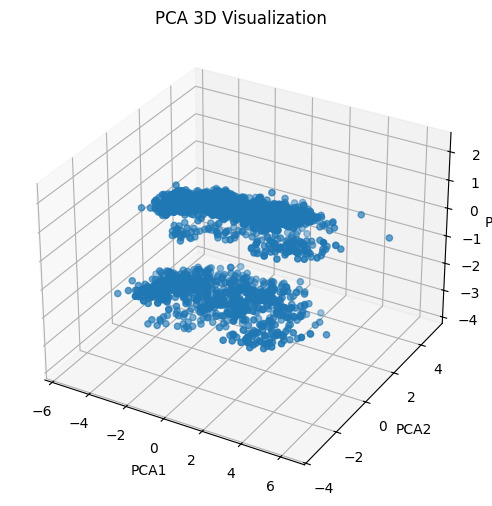

In [51]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
x_pca = pca.fit_transform(x_scaled)
ax.scatter(x_pca[:,0], x_pca[:,1], x_pca[:, 2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("PCA 3D Visualization")

Analyze K value

1. Elbow method

In [52]:
!pip install kneed

In [53]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1,11):
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit_predict(x_pca)
  wcss.append(kmeans.inertia_)

In [54]:
knee = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

In [55]:
print("Optial k value = ", optimal_k)

Optial k value =  4


Text(0, 0.5, 'WCSS')

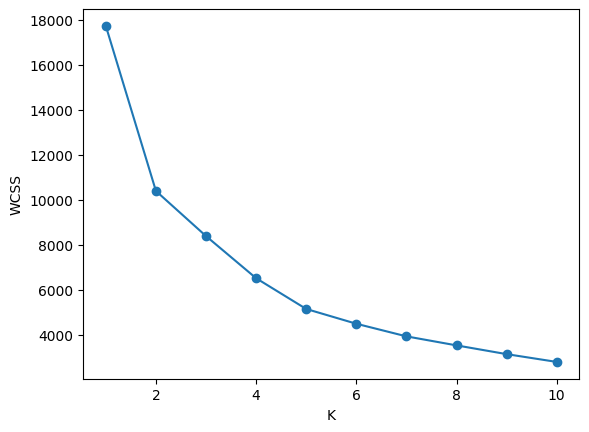

In [56]:
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")

2. Silhoutte score

Text(0, 0.5, 'Silhoutte Score')

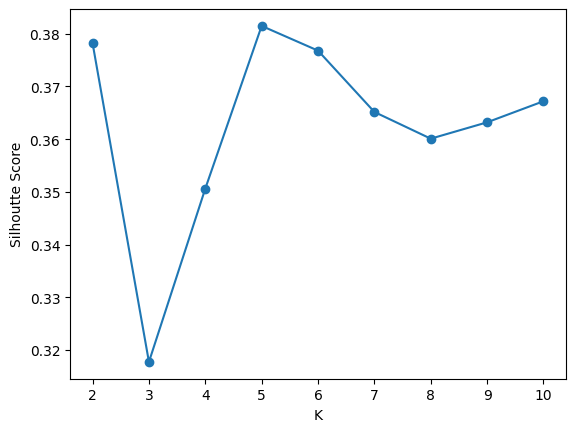

In [57]:
from sklearn.metrics import silhouette_score
scores = []
for k in range(2,11):
  kmeans = KMeans(n_clusters=k, random_state=42)
  labels = kmeans.fit_predict(x_pca)
  score = silhouette_score(x_pca, labels)
  scores.append(score)

plt.plot(range(2,11), scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhoutte Score")

Text(0, 0.5, 'Silhoutte Score')

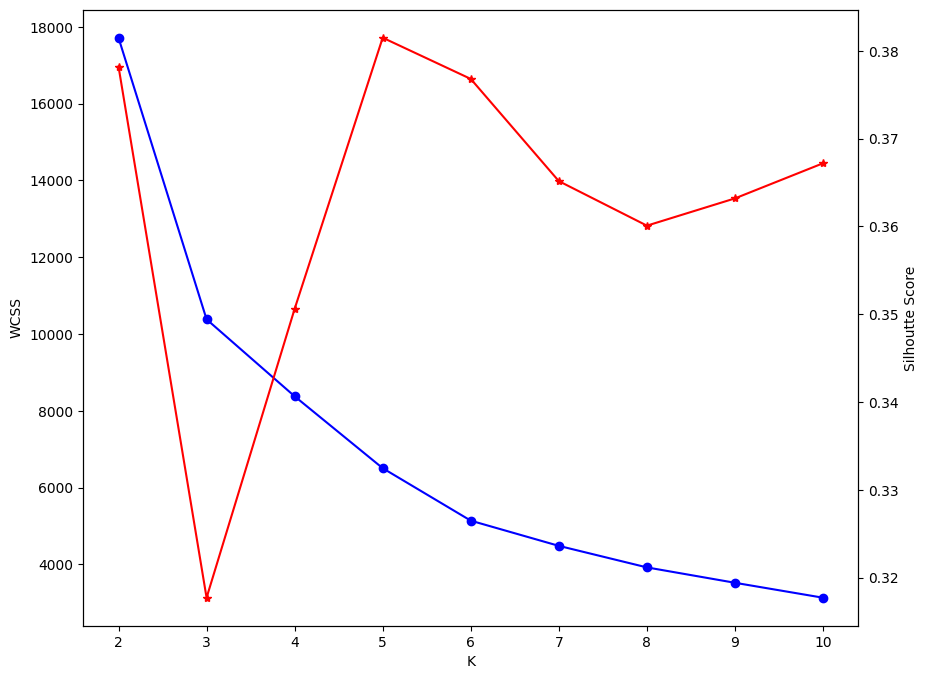

In [58]:
# Combined plot

k_range = range(2,11)
fig, ax1 = plt.subplots(figsize=(10,8))
ax1.plot(k_range, wcss[:len(k_range)], marker='o', color='blue')
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker='*', color='red', linestyle='-')
ax2.set_ylabel("Silhoutte Score")
ax2.set_ylabel("Silhoutte Score")

Clustering

In [59]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(x_pca)

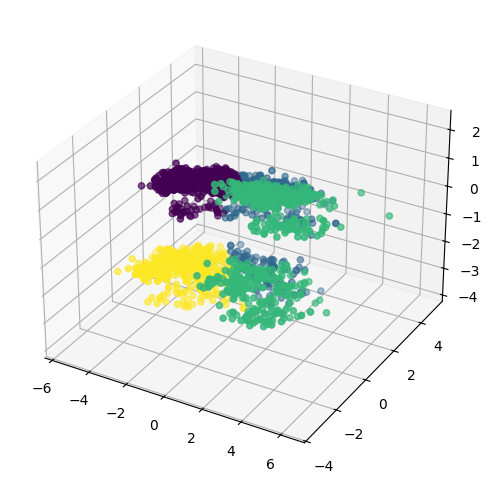

In [60]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x_pca[:,0], x_pca[:, 1], x_pca[:, 2], c=labels_kmeans)

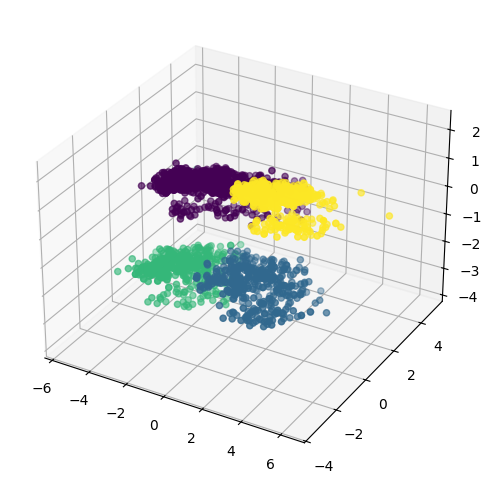

In [61]:
# Agglomerative
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=4, linkage="ward")
agg_labels = agg.fit_predict(x_pca)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x_pca[:,0], x_pca[:,1], x_pca[:,2], c=agg_labels)

In [75]:
X["cluster"] = agg_labels

In [76]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Single,Living_With_Together,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,0.0,1.0,0.0,1
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,0.0,1.0,3
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

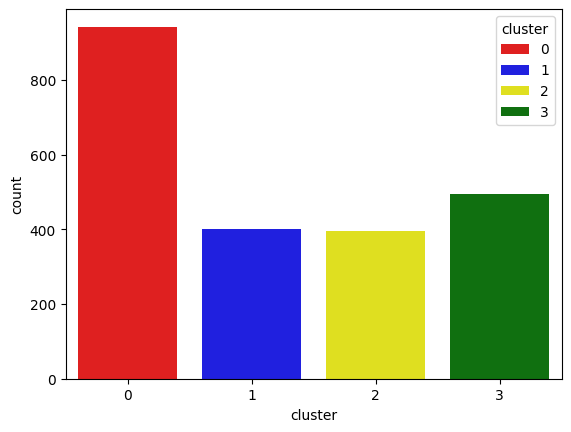

In [77]:
pal = ["red", "blue", "yellow", "green"]
sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

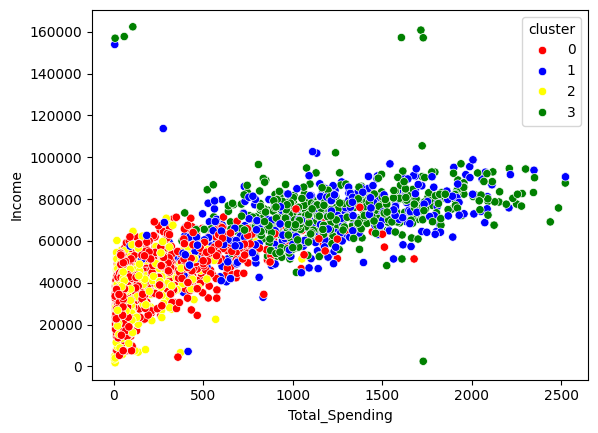

In [78]:
sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["cluster"], palette=pal)

In [79]:
# Cluster Summary
cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        40410.967656  49.152704           2.656416         3.233298   
1        68508.315461  49.947631           2.127182         5.733167   
2        35110.039141  48.618687           2.409091         2.398990   
3        73957.847782  48.772177           1.792339         5.729839   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   1.066808           4.308590           6.303287  0.010604   
1                   4.675810           8.172070           4.034913  0.004988   
2                   0.674242           3.303030           6.704545  0.012626   
3                   5.659274           8.691532           3.379032  0.006048   

         Response        Age  Customer_tenure  Total_Spending  Total_Children  \
clust